## 2 Solving Linear Equations $A\mathbf x = \mathbf b$

The matrices in this chapter are square: $n$ by $n$. $A\mathbf x = \mathbf b$ gives $n$ equations (one from each row of $A$).

**$A\mathbf x = \mathbf b$ has the only one solution**, if $A$ has an inverse $A^{-1}$ with $A^{-1}A=I$ and $AA^{-1}=I$. Multiplying $A\mathbf x = \mathbf b$ by $A^{-1}$ produces the symbolic solution $\mathbf x = A^{-1}\mathbf b$.

This chapter aims to find that solution $x$.
But we **don’t compute $A^{-1}$**. (That would solve $Ax = b$ for every possible $b$.)

We go forward **column by column**, assuming that $A$ has independent columns. We only stop if this proves wrong.

At the end, $Ax = b$ has changed to a **triangular system**
$$
Ux = c,
$$
and now the solution $x$ is easy to find.




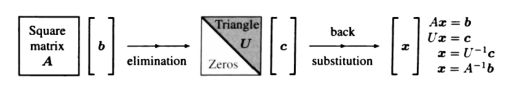

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"images\2-1.png")
plt.imshow(img)
plt.axis("off")
plt.show()

To describe all the steps, we need matrices. **This is the point of linear algebra!**

A simple elimination matrix $E_{ij}$ produces a zero where row $i$ meets column $j$ $(i > j)$. Overall, an elimination matrix $E$ multiplies $A$ to give
$$
EA = U.
$$
And we multiply $U$ by an inverse matrix
$$
L = E^{-1}
$$
to come back to $A$.

Here are key matrices in this chapter:

- Coefficient matrix $A$
- Upper triangular matrix $U$
- Lower triangular matrix $L$
- Elimination matrix $E_{ij}$
- Overall elimination matrix $E$
- Inverse matrix $A^{-1}$
- Permutation matrix $P$
- Transpose matrix $A^T$
- Symmetric matrix $S = S^T$

Our goal is to explain all the steps from
$$
A \;\longrightarrow\; EA = U \;\longrightarrow\; A = E^{-1}U = LU \;\longrightarrow\; x.
$$

(If the steps fail, this signals that $Ax = b$ has no solution for most $b$.)

Every computer system has a code to find the triangular matrix $U$ and then the solution $x$.
Those codes are used so often that elimination adds up to the **greatest cost in all of scientific computing**.

But the codes are highly engineered, and we don’t know a better way to solve $Ax = b$.

Section 2.5 introduces difference matrices from Computational Science and Engineering.


### 2.1 Elimination and Back Substitution

$$\boxed{
\begin{aligned}
1.\;& \text{Elimination subtracts } \ell_{ij}\text{ times row } j \text{ from row } i,
      \text{ leaving a zero in row } i.\\
2.\;& Ax = b \text{ becomes } Ux = c
      \;(\text{or else } Ax = b \text{ is proved to have no solution}).\\
3.\;& \text{Then } Ux = c \text{ is solved by back substitution,}
      \text{ because } U \text{ is upper triangular.}
\end{aligned}
}$$

This chapter explains a systematic way to solve $Ax = b$: $n$ equations for $n$ unknowns.

The $n \times n$ matrix $A$ is given and the $n \times 1$ column vector $b$ is given. There may be **no vector** $x = (x_1, x_2, \ldots, x_n)$ that solves $Ax = b$,
- or there may be **exactly one solution**,
- or there may be **infinitely many solution vectors** $x$.

Our job is to decide among these three possibilities and to find all solutions. Here are the possibilities with $n = 2$.

1. Exactly one solution to $Ax = b$

      In this case, $A$ has **independent columns**. The rank of $A$ is 2. The only solution to $Ax = 0$ is $x = 0$. $A$ has an inverse matrix $A^{-1}$.

      **Example with one solution:**  
      $$
      (x, y) = (1, 1)
      $$

      $$
      \begin{cases}
      2x + 3y = 5 \\
      4x + 2y = 6
      \end{cases}
      \qquad
      A =
      \begin{pmatrix}
      2 & 3 \\
      4 & 2
      \end{pmatrix}
      $$

      Independent columns: $(2,4)$ and $(3,2)$.

2. No solution to $Ax = b$

      In this case, $b$ is **not a combination of the columns of $A$**. In other words, $b \notin \text{Col}(A)$. The rank of $A$ is 1.

      **Example with no solution:**

      $$
      \begin{cases}
      2x + 3y = 6 \\
      4x + 6y = 15
      \end{cases}
      \qquad
      A =
      \begin{pmatrix}
      2 & 3 \\
      4 & 6
      \end{pmatrix}
      $$

      Dependent columns: $(2,4)$ and $(3,6)$.

      Subtract 2 times the first equation from the second to get:
      $$
      0 = 3
      $$
      No solution.

3. Infinitely many solutions

      There will be **infinitely many solutions** to $Ax = 0$ when the columns of $A$ are **not independent**. This is the meaning of dependent columns — many ways to produce the zero vector $b = 0$. We can multiply a solution $X$ by any number $\alpha$.

      If there is one solution to $Ax = b$, then we can add any solution to $AX = 0$. All vectors $x + \alpha X$ solve the same equations, so we have many solutions.

      For any number $\alpha$,
      $$
      A(x + \alpha X) = Ax + \alpha AX = b + 0 = b. \tag{1}
      $$

      **Example with infinitely many solutions:**

      $$
      \begin{cases}
      2x + 3y = 6 \\
      4x + 6y = 12
      \end{cases}
      \qquad
      A =
      \begin{pmatrix}
      2 & 3 \\
      4 & 6
      \end{pmatrix}
      $$

      $A$ has dependent columns and $b \in \text{Col}(A)$.


Those equations $Ax = b$ are solved by $x = 0,\; y = 2$. But there are more solutions because
$
X = (3, -2)
$
solves $AX = 0$. Then
$
2X = (6, -4)
$
also solves $A(2X) = 0$.

All vectors $\alpha X$ can be added to the particular solution
$
x = (0, 2)
$
to produce more solutions:
$$
x + \alpha X = (0 + 3\alpha,\; 2 - 2\alpha),
$$
which is a **line of solutions** to the two equations $Ax = b$.

This chapter will start with
$
Ux = c:
$
one solution, easy to find. Then we explain how $Ax = b$ leads to $Ux = c$. When this fails, a row exchange may save it. When row exchanges also fail, $A$ has no inverse matrix $A^{-1}$. Its columns are dependent (cases 2–3).


#### Back Substitution to Solve $U\mathbf x = \mathbf c$

This chapter will give a systematic way to decide between those possibilities 1,2,3: One solution, no solution, infinitely many solutions. This system is called **elimination**.

Let me show you the ideal result. Elimination produces an **upper triangular matrix**. That matrix is called $U$. Then $Ax = b$ leads to $Ux = c$, which we easily solve.

- **Apply elimination to $Ax = b$** (next page)  
- **The result is $Ux = c$** (here)  
- **Back substitution now finds $x$**

$$
Ux = c \quad \text{is}
\quad
\begin{pmatrix}
2 & 3 & 4 \\
0 & 5 & 6 \\
0 & 0 & 7
\end{pmatrix}
\begin{pmatrix}
x_1 \\
x_2 \\
x_3
\end{pmatrix}
=
\begin{pmatrix}
19 \\
17 \\
14
\end{pmatrix}
$$

That letter $U$ stands for **upper triangular**. The matrix has all zeros below its diagonal. **Highly important:** The *pivots* $2, 5, 7$ on the main diagonal of $U$ are **not zero**. Then we can solve the equations by going from bottom to top: find $x_3$, then $x_2$, then $x_1$.

$$\boxed{
\begin{aligned}
&\textbf{Back substitution:}\;
\text{The last equation } 7x_3 = 14 \text{ gives } x_3 = 2. \\

&\textbf{Work upwards:}\;
\text{The next equation } 5x_2 + 6(2) = 17 \text{ gives } x_2 = 1. \\

&\textbf{Upwards again:}\;
\text{The first equation } 2x_1 + 3(1) + 4(2) = 19 \text{ gives } x_1 = 4. \\

&\textbf{Conclusion:}\;
\text{The only solution to this example } Ux = c \text{ is } \boxed{x = (4,\,1,\,2).} \\

&\textbf{Special note:}\;
\text{In solving for } x_1, x_2, x_3 \text{ we needed to divide by the pivots } 2,\,5,\,7.
\end{aligned}
}$$

**Equations $A\mathbf x=\mathbf b\quad$ Elimination to $U\mathbf x=\mathbf c\quad$ Back substitution to $\mathbf x=U^{-1}\mathbf c=A^{-1}b$**

**Note.** We would not allow the number zero to be a pivot. That would destroy our plan because an equation like $0x_1 = 2$ or $0x_2 = 5$ or $0x_3 = 8$ has no solution. Back substitution will break down with a zero in any pivot position (on the diagonal of $U$).

**The test for independent columns in $A$ is $n$ nonzero pivots in $U$(after possible row exchanges).**


#### From $A$ to $U$ and $\mathbf b$ to $\mathbf c$: Elimination in Each Column

First comes a matrix $A$ (independent columns) that will require no row exchanges. We will apply elimination matrices $E_{21}$ then $E_{31}$ then $E_{32}$. $A$ and $\mathbf b$ will change to $U$ and $\mathbf c$.

The starting matrix is $A$.
The first pivot is $2$.
The right side is $b$.

$$
A =
\begin{pmatrix}
2 & 3 & 4 \\
4 & 11 & 14 \\
2 & 8 & 17
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
19 \\
55 \\
50
\end{pmatrix}
\tag{2}
$$

$E_{21}$ multiplies equation 1 by 2 and subtracts from equation 2. You see the new zero.

$$
E_{21} =
\begin{pmatrix}
1 & 0 & 0 \\
-2 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix},
\qquad
E_{21}A =
\begin{pmatrix}
2 & 3 & 4 \\
0 & 5 & 6 \\
2 & 8 & 17
\end{pmatrix},
\qquad
E_{21}b =
\begin{pmatrix}
19 \\
17 \\
50
\end{pmatrix}
\tag{3}
$$

This produced the desired zero in column 1. It changed equation 2. To produce another zero, we subtract row 1 from row 3 using $E_{31}$. This completes elimination in column 1:

$$
E_{31} =
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-1 & 0 & 1
\end{pmatrix},
\qquad
E_{31}E_{21}A =
\begin{pmatrix}
2 & 3 & 4 \\
0 & 5 & 6 \\
0 & 5 & 13
\end{pmatrix},
\qquad
E_{31}E_{21}b =
\begin{pmatrix}
19 \\
17 \\
31
\end{pmatrix}
\tag{4}
$$

Move now to column 2 and row 2 (the second pivot row). The pivot is 5, on the diagonal. To eliminate the 5 below it, multiply row 2 by the number 1 and subtract from row 3.

$$
E_{32} =
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & -1 & 1
\end{pmatrix},
\qquad
U =
\begin{pmatrix}
2 & 3 & 4 \\
0 & 5 & 6 \\
0 & 0 & 7
\end{pmatrix},
\qquad
c =
\begin{pmatrix}
19 \\
17 \\
14
\end{pmatrix}
\tag{5}
$$

$
E_{32}E_{31}E_{21}A = U
$ is triangular. $x = (4,1,2)$ solves $Ux = c$. Since $U$ has $2,5,7$ on its diagonal, we know that back substitution will succeed. The columns of $U$ are independent (and therefore the columns of the original $A$ were independent). The matrices $A$ and $U$ have full rank. 

**We can summarize the elimination steps when no row exchanges are involved:**

$$
\boxed{
\begin{aligned}
&\text{Use the first equation to produce zeros in column 1 below the first pivot.}  \\
&\text{Use the new second equation to clear out column 2 below pivot 2 in row 2.}  \\
&\text{Continue to column 3. The expected result is an upper triangular matrix }U. \\
\end{aligned}
}
$$

Elimination on $A$ produces $U$. The same steps were applied to the right hand side $b$. Those steps produce a new right hand side $c$.
The new equations $Ux = c$ (equivalent to the old equations $Ax = b$) are solved by back substitution: $x = (4,1,2)$.





#### Possible Breakdown of Elimination

Elimination might fail. **Zero can appear in a pivot position**. Here is an example: **Zero in pivot 2 from elimination in column 1**

$$A =
\begin{pmatrix}
2 & 3 & 4 \\
4 & 6 & 14 \\
2 & 8 & 17
\end{pmatrix}
\;\longrightarrow\;
\begin{pmatrix}
2 & 3 & 4 \\
0 & 0 & 6 \\
0 & 5 & 13
\end{pmatrix}
= B$$

**Exchange row 2 with the zero for row 3 with the 5.**

$$PB =
\begin{pmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & 1 & 0
\end{pmatrix}
\begin{pmatrix}
2 & 3 & 4 \\
0 & 0 & 6 \\
0 & 5 & 13
\end{pmatrix}
=
\begin{pmatrix}
2 & 3 & 4 \\
0 & 5 & 13 \\
0 & 0 & 6
\end{pmatrix}$$

For this small example, the row exchange is all we need. It produced $U$ with nonzero pivots $2, 5, 6$. But a slightly different matrix $A^*$ would lead to a bad situation: **no pivet is available in column $2$**. For example, **Dependent column $U^*$ is not invertible, $A^*$ is not invertible**.

$$A^* =
\begin{pmatrix}
2 & 3 & 4 \\
4 & 6 & 14 \\
2 & 3 & 17
\end{pmatrix}
\;\longrightarrow\;
\begin{pmatrix}
2 & 3 & 4 \\
0 & 0 & 6 \\
0 & 0 & 13
\end{pmatrix}
= U^*
\tag{6}$$

At this point elimination is helpless in column $2$. *No second pivot*. This misfortune tells us that **the matrix $A^*$ did not have full rank**.

##### (PS): For an $n \times n$ matrix $A$, the following statements are **equivalent**:
1. $A$ is invertible.
2. $A^{-1}$ exists.
3. The equation $A\mathbf x = 0$ has only the trivial solution ($\mathbf 0$ solution).
4. Elimination on $A$ produces $n$ **nonzero pivots**.
5. The upper triangular matrix $U$ obtained from elimination has no zeros on its diagonal.
6. $\operatorname{rank}(A) = n$.
7. The columns of $A$ are linearly independent.
8. The rows of $A$ are linearly independent.
9. $\det(A) \neq 0$.

If any one of these conditions fails, then all of them fail.

#### Dependent or Independent Columns

$$
\boxed{
\text{A triangular matrix } U \text{ has full rank exactly when its main diagonal has no zeros.}
}
$$

How do we know that a zero on the diagonal of $U^*$ leads to dependent columns?

$$
\boxed{
U^* =
\begin{pmatrix}
* & * & * & * \\
0 & * & * & * \\
0 & 0 & 0 & * \\
0 & 0 & 0 & *
\end{pmatrix}=
\begin{aligned}
&\text{Upper triangular with an extra zero on its diagonal.} \\
&\text{This matrix is singular (not full rank 4).} \\
&\text{The first three columns are dependent.} \\
&\text{The last two rows are dependent.}
\end{aligned}
}
$$


#### The Row Picture and the Column Picture

The next pictures will show the three possibilities for $Ax = b$: No solution or a line of solutions or one solution. There are two ways to see this. We start with the rows of $A$ and we graph the two equations: the row picture. We have trouble if the lines don’t meet.

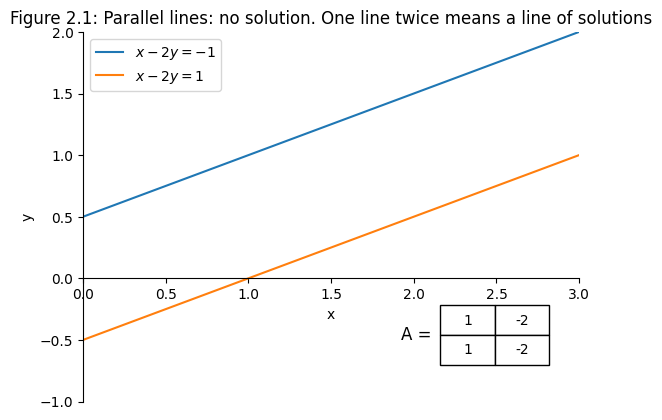

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 3, 400)

y1 = (x + 1) / 2
y2 = (x - 1) / 2

fig, ax = plt.subplots()

ax.plot(x, y1, label=r"$x - 2y = -1$")
ax.plot(x, y2, label=r"$x - 2y = 1$")

ax.set_xlim(0, 3)
ax.set_ylim(-1, 2)

# Move axes to (0,0)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.set_title("Figure 2.1: Parallel lines: no solution. One line twice means a line of solutions")

left, bottom, width, height = 0.72, 0.10, 0.22, 0.16

cell_text = [["1", "-2"],
             ["1", "-2"]]

tbl = ax.table(
    cellText=cell_text,
    cellLoc="center",
    bbox=[left, bottom, width, height]
)

ax.text(
    left - 0.08, bottom + height/2,
    "A =",
    transform=ax.transAxes,  
    fontsize=12,
    va="center"
)

plt.show()



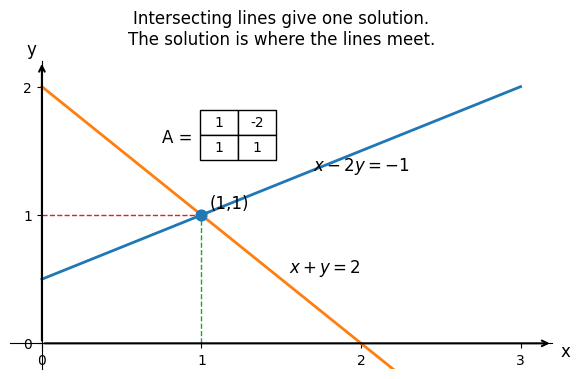

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# x range
x = np.linspace(0, 3, 400)

# Lines:
# x - 2y = -1  -> y = (x + 1)/2
# x + y = 2    -> y = 2 - x
y1 = (x + 1) / 2
y2 = 2 - x

fig, ax = plt.subplots(figsize=(7, 4))

# Plot the two lines
ax.plot(x, y1, linewidth=2, label=r"$x - 2y = -1$")
ax.plot(x, y2, linewidth=2, label=r"$x + y = 2$")

# Intersection point (1,1)
ax.scatter([1], [1], s=60, zorder=5)
ax.text(1.05, 1.05, "(1,1)", fontsize=12)

# Limits
ax.set_xlim(-0.2, 3.2)
ax.set_ylim(-0.2, 2.2)

# Move axes to (0,0) and hide top/right spines
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")

# Add arrowheads to axes
ax.annotate("", xy=(3.2, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=1.5))
ax.annotate("", xy=(0, 2.2), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=1.5))

# Axis labels near arrowheads
ax.text(3.25, -0.1, "x", fontsize=12)
ax.text(-0.1, 2.25, "y", fontsize=12)

# Dotted helper lines through (1,1)
ax.plot([1, 1], [0, 1], linestyle="--", linewidth=1)
ax.plot([0, 1], [1, 1], linestyle="--", linewidth=1)

# (Optional) Draw a "box-like" thick polyline similar to the textbook figure

ax.plot([2, 2], [0, 0], linewidth=3)   # small bottom segment

# Put equation labels near lines (manual placement)
ax.text(1.7, 1.35, r"$x - 2y = -1$", fontsize=12)
ax.text(1.55, 0.55, r"$x + y = 2$", fontsize=12)

# Add matrix A on the left using a table (no LaTeX dependency)
# Place it in axes coordinates so it stays fixed
ax.text(0.28, 0.75, "A =", transform=ax.transAxes, fontsize=12, va="center")

tbl = ax.table(
    cellText=[["1", "-2"],
              ["1", "1"]],
    cellLoc="center",
    bbox=[0.35, 0.68, 0.14, 0.16]  # [left, bottom, width, height] in axes coords
)

# Title/caption like the book
ax.set_title("Intersecting lines give one solution.\nThe solution is where the lines meet.", fontsize=12, pad=12)

# Clean up ticks to look more like the figure
ax.set_xticks([0, 1, 2, 3])
ax.set_yticks([0, 1, 2])

plt.show()


If we had three equations for $x, y$ and $z$ in 3-dimensional space, this row picture becomes hard to draw. The column picture is much easier in three or more dimensions.

The **column picture** just shows column vectors: The goal of $A\mathbf x = \mathbf b$ is to combine the columns of $A$ so as to produce the vector $\mathbf b$. This is always possible when the columns of $A$ ($n$ vectors in $n$-dimensional space) are independent. Then the column space of $A$ contains all vectors $\mathbf b$ in $\mathbb R^n$". There is exactly one combination $A\mathbf x$ of the columns that equals $\mathbf b$. Elimination finds that solution $\mathbf x$.

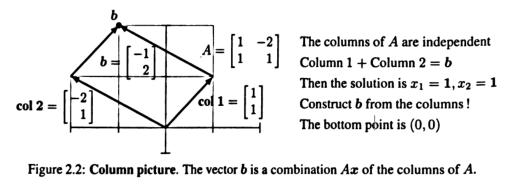

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"images\2-2.png")
plt.imshow(img)
plt.axis("off")
plt.show()

#### Examples of Elimination and Permutation

This chapter will go on to express the whole process using matrices.  
An elimination matrix $E$ will act on $Ax=b$. In case zero appears in a pivot position, use a permutation matrix $P$. The final result is an upper triangular $U$ and a new right hand side $c$. Then $Ux=c$ is solved by back substitution. In reality a computer takes those steps ($x=A\backslash b$ in MATLAB). But it is good to solve a few examples—not too many—by hand. You see the steps to $Ux=c$ and then to the solution $x$. This page contains a variety of examples, hopefully to show the way.

$$
A=
\begin{bmatrix}
2 & 4 & -2\\
4 & 9 & -3\\-2 & -3 & 7
\end{bmatrix}
\;\xrightarrow{E_{21}}\;
\begin{bmatrix}
2 & 4 & -2\\
0 & 1 & 1\\-2 & -3 & 7
\end{bmatrix}
\;\xrightarrow{E_{31}}\;
\begin{bmatrix}
2 & 4 & -2\\
0 & 1 & 1\\
0 & 1 & 5
\end{bmatrix}
\;\xrightarrow{E_{32}}\;
\begin{bmatrix}
2 & 4 & -2\\
0 & 1 & 1\\
0 & 0 & 4
\end{bmatrix}
=U
$$

Those elimination steps $E_{21}$ and $E_{31}$ and $E_{32}$ produced zeros in positions $(2,1)$ and $(3,1)$ and $(3,2)$. The matrices $E$ have $-2$ and $+1$ and $-1$ in those positions. The same steps $E_{21},E_{31},E_{32}$ must be applied to the right hand side $b$, to keep the equations correct.

$$
b=
\begin{bmatrix}
2\\
8\\
10
\end{bmatrix}
\;\xrightarrow{E_{21}}\;
\begin{bmatrix}
2\\
4\\
10
\end{bmatrix}
\;\xrightarrow{E_{31}E_{21}}\;
\begin{bmatrix}
2\\
4\\
12
\end{bmatrix}
\;\xrightarrow{E_{32}E_{31}E_{21}}\;
Eb=c=
\begin{bmatrix}
2\\
4\\
8
\end{bmatrix}
$$

There is a simple way to make sure that operations on the matrix $A$
(left side of equations) are also executed on $b$ (right side of equations). The good way is to include $b$ as an extra column with $A$.
The combination $[\,A\;\;b\,]$ is called an augmented matrix.

$$
[\,A\;\;b\,]=
\begin{bmatrix}
2 & 4 & -2 & 2\\
4 & 9 & -3 & 8\\-2 & -3 & 7 & 10
\end{bmatrix}
\;\xrightarrow{E}\;
\begin{bmatrix}
2 & 4 & -2 & 2\\
0 & 1 & 1 & 4\\
0 & 0 & 4 & 8
\end{bmatrix}
=
[\,U\;\;c\,].
\tag{7}
$$


### 2.2 Elimination Matrices and Inverse Matrices

For a $3$ by $3$ matrix:

$$\boxed{
\begin{aligned}
1.\;& \text{Elimination multiplies } A \text{ by } E_{21}, \ldots, E_{n1}, \text{ then } E_{32}, \ldots, E_{n2}, \text{ so that } EA = U. \\

2.\;& \text{In reverse order, the inverses of the } E\text{'s multiply } U \text{ to recover } A = E^{-1}U.\text{ This is } A = LU. \\

3.\;& A^{-1}A = I \text{ and } (LU)^{-1} = U^{-1}L^{-1}. \text{ Then } Ax = b \text{ becomes } x = A^{-1}b = U^{-1}L^{-1}b.
\end{aligned}
}$$

**The basic elimination step subtracts a multiple $\ell_{ij}$ of equation $j$ from equation $i$.** We always speak about subtractions as elimination proceeds. If the first pivot is $a_{11}=3$ and below it is $a_{21}=-3$., we could just subtract $\ell_{21}=-1$ times equation $1$ to equation $2$.

$$\text{Row}_i=\text{Row}_i-\ell_{ij}\cdot\text{Row}_j$$

$$\ell_{ij}=\frac{a_{ij}}{a_{jj}}$$

Here is the matrix that subtracts $2$ times row $1$ from row $3$: Rows $1$ and $2$ stay the same.

$$E_{ij}=I-\ell_{ij}e_ie_j^T$$

$$
\text{Elimination matrix } E_{ij} = E_{31}
\quad
E_{31}
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-2 & 0 & 1
\end{bmatrix}
$$

If no row exchanges are needed, then three elimination matrices $E_{21}$ and $E_{31}$ and $E_{32}$ will produce three zeros below the diagonal. This changes $A$ to the triangular $U$:

$$\boxed{
E = E_{32} E_{31} E_{21}, \qquad EA = U \ \text{(upper triangular)}.
}
\tag{1}$$


$
\textbf{Example 1}\quad
E_{21} \text{ and then } E_{31} \text{ subtract multiples of row 1 from rows 2 and 3 of } A:
$

$$
E_{31} E_{21} A
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-2 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
1 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
3 & 1 & 0 \\
-3 & 1 & 1 \\
6 & 8 & 4
\end{bmatrix}
=
\begin{bmatrix}
3 & 1 & 0 \\
0 & 2 & 1 \\
0 & 6 & 4
\end{bmatrix}
$$

$
\text{To produce a zero in column 2, } E_{32} \text{ subtracts } \ell_{32}= 3 \text{ times the new row 2 from row 3:}
$

$$
(E_{32})(E_{31}E_{21}A)
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & -3 & 1
\end{bmatrix}
\begin{bmatrix}
3 & 1 & 0 \\
0 & 2 & 1 \\
0 & 6 & 4
\end{bmatrix}
=
\begin{bmatrix}
3 & 1 & 0 \\
0 & 2 & 1 \\
0 & 0 & 1
\end{bmatrix}
= U
$$

The inverse of each matrix $E_{ij}$ adds back $\ell_{ij}$(row $j$) to row $i$. This leads to the inverse of their product $E=E_{32}E_{31}E_{21}$. That inverse of $E$ is special. We call it $L$.

$$E_{ij}^{-1}=I+\ell_{ij}e_ie_j^T$$

$$L=E^{-1}=E_{21}^{-1}E_{31}^{-1}E_{32}^{-1}$$

For example:

$$
E_{31} =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-2 & 0 & 1
\end{bmatrix}
\quad
\ell_{31} = 2
$$
$$
E_{31}^{-1} =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
2 & 0 & 1
\end{bmatrix}
$$



### The Facts About Inverse Matrices

Suppose $A$ is a square matrix. We look for an "inverse matrix" $A^{-1}$ of the same size, so that $A^{-1}$ times $A$ equals $I$. **Whatever $A$ does, $A^{-1}$ undoes.** Their product is the identity matrix—which does nothing to a vector, so $A^{-1}Ax=x$. **But $A^{-1}$ might not exist.**

The $n$ by $n$ matrix $A$ needs $n$ independent columns to be invertible. Then $A^{-1}A=I$. The matrix $A^{-1}$ is called **"A inverse"**.

$$\boxed{
\begin{aligned}
\textbf{Definition: }
&\text{The matrix } A \text{ is invertible if there exists a matrix } A^{-1} \\
&\text{such that } A^{-1}A = I \text{ and } AA^{-1} = I\quad\text{(Two-sided inverse)}
\end{aligned}\tag{4}
}$$


**Not all matrices have inverses!** Here are seven “notes” about $A^{-1}$.
1. **The inverse exists if and only if elimination produces $n$ pivots** (row exchanges are allowed). Elimination solves $A\mathbf x = \mathbf b$ without explicitly using the matrix $A^{-1}$.
2. **The matrix $A$ cannot have two different inverses.** Suppose $BA=I$ and also $AC=I$. Then $B=C$, according to this "proof by parentheses" = associative law.

    $$B(AC) = (BA)C \quad \text{gives} \quad BI = IC \ \text{or} \ B = C.\tag{5}$$
3. If $A$ is invertible, the one and only solution to $A\mathbf{x}=\mathbf{b}$ is $\mathbf{x}=A^{-1}\mathbf{b}$:

    $$\boxed{
    \text{Multiply } Ax = b \text{ by } A^{-1}. 
    \quad \text{Then } x = A^{-1}Ax = A^{-1}b.
    }$$
4. (Important) Suppose there is a nonzero vector $\mathbf x$ such that $A\mathbf x = \mathbf 0$. Then $A$ has dependent columns. It cannot have an inverse. No matrix can bring $\mathbf 0$ back to $\mathbf x$.

    If $A$ is invertible, then $A\mathbf x = \mathbf 0$ only has the zero solution $\mathbf x = A^{-1}\mathbf 0=\mathbf 0$
5. A square matrix is invertible if and only if its columns are independent.
6. A $2$ by $2$ matrix is invertible if and only if the number $ad — bc$ is not zero:

    $$\boxed{
    \begin{bmatrix}
    a & b \\
    c & d
    \end{bmatrix}^{-1}
    =
    \frac{1}{ad - bc}
    \begin{bmatrix}
    d & -b \\
    -c & a
    \end{bmatrix}
    }\tag{6}$$

    This number $ad-bc$ is the determinant of $A$. A matrix is invertible if its determinant is not zero. The test for $n$ pivots is usually decided before the determinant appears.
7. A triangular matrix has an inverse provided no diagonal entries $d_i$ are zero:

    $$\text{If } 
    A =
    \begin{bmatrix}
    d_1 & \times & \times & \times \\
    0   & \bullet & \times & \times \\
    0   & 0   & \bullet & \times \\
    0   & 0   & 0   & d_n
    \end{bmatrix},
    \quad \text{then} \quad
    A^{-1} =
    \begin{bmatrix}
    \dfrac{1}{d_1} & \times & \times & \times \\
    0   & \bullet & \times & \times \\
    0   & 0   & \bullet & \times \\
    0   & 0   & 0   & \dfrac{1}{d_n}
    \end{bmatrix}.$$

### The Inverse of a Product $AB$

$$\boxed{
\begin{aligned}
&\text{If } A \text{ and } B \text{ are invertible (same size), then the inverse of } AB \text{ is } B^{-1}A^{-1}.\\
&(AB)^{-1} = B^{-1}A^{-1},\qquad
(AB)(B^{-1}A^{-1}) = AIA^{-1} = AA^{-1} = I
\end{aligned}\tag{7}
}$$

$$\boxed{\text{Reverse order}\quad
(ABC)^{-1} = C^{-1} B^{-1} A^{-1}
}\tag{8}$$

**Example 4** Inverse of an elimination matrix. 

If $E$ subtracts $5$ times row $1$ from row $2$, then $E^{-1}$ adds $5$ times row $1$ to row $2$:

$$\boxed{
E =
\begin{bmatrix}
1 & 0 & 0 \\
-5 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix},
\qquad
E^{-1} =
\begin{bmatrix}
1 & 0 & 0 \\
5 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
}$$

**Example 5** Suppose $F$ subtracts $4$ times row $2$ from row $3$, and $F^{-1}$ adds it back:

$$F =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & -4 & 1
\end{bmatrix},
\qquad
F^{-1} =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 4 & 1
\end{bmatrix}$$

Now multiply $F$ by the matrix $E$ in Example $4$ to find $FE$. Also multiply $E^{-1}$ times $F^{-1}$ to find $(FE)^{-1}$. Notice the order $FE$ and $E^{-1}F^{-1}$!

$$FE =
\begin{bmatrix}
1 & 0 & 0 \\
-5 & 1 & 0 \\
20 & -4 & 1
\end{bmatrix}
\quad \text{is inverted by} \quad
E^{-1}F^{-1} =
\begin{bmatrix}
1 & 0 & 0 \\
5 & 1 & 0 \\
0 & 4 & 1
\end{bmatrix}.\tag{9}$$
 

### $L$ is the Inverse of $E$

$E$ is the product of all the elimination matrices $E_{ij}$, taking $A$ into its upper triangular form $EA = U$. We are assuming for now that no row exchanges are involved ($P = I$). The difficulty with $E$ is that multiplying all the separate elimination steps $E_{ij}$ does not produce
a good formula. But the inverse matrix $E^{-1}$ becomes beautiful when we multiply the inverse steps $E_{ij}^{-1}$. Remember that those steps come in the **opposite order**.

With $n=3$, the complication for $E = E_{32}E_{31}E_{21}$ is in the bottom left corner:

$$E
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & -\ell_{32} & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-\ell_{31} & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
-\ell_{21} & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 \\
-\ell_{21} & 1 & 0 \\
\ell_{32}\ell_{21} - \ell_{31} & -\ell_{32} & 1
\end{bmatrix}.
\tag{10}$$

Watch how that confusion disappears for $E^{-1} = L$. Reverse order is the good way:

$$E^{-1}
=
\begin{bmatrix}
1 & 0 & 0 \\
\ell_{21} & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
\ell_{31} & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & \ell_{32} & 1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 \\
\ell_{21} & 1 & 0 \\
\ell_{31} & \ell_{32} & 1
\end{bmatrix}
= L.
\tag{11}$$

All the multipliers $\ell_{ij}$ appear in their correct positions in $L$. The next section will show
that this remains true for all matrix sizes. Then $EA = U$ becomes $A = LU$. Equation (11) is the key to this chapter: Each $\ell_{ij}$ is in its place for $E^{-1}=L$.

### 2.3 Matrix Computations and $A = LU$

$$\boxed{
\begin{aligned}
1.\;& \text{The elimination steps from } A \text{ to } U \text{ cost } \tfrac{1}{3}n^3 
\text{ multiplications and subtractions.} \\
2.\;& \text{Each right side } b \text{ costs only } n^2: 
\text{ forward to } Ux = c, \text{ then back-substitution for } x. \\
3.\;& \text{Elimination without row exchanges factors } A \text{ into } LU \text{ (two proofs of } A = LU\text{).}
\end{aligned}
}$$

To compute the inverse of an $ n \times n $ matrix $ A $, we begin with the defining identity
$$
AA^{-1} = I.
$$

Write the inverse column-wise as
$$
A^{-1} = [x_1 \; x_2 \; \cdots \; x_n].
$$
Then the matrix equation $ AA^{-1} = I $ is equivalent to **$ n $ linear systems**
$$
Ax_1 = e_1,\quad Ax_2 = e_2,\quad \dots,\quad Ax_n = e_n,
$$
where $ e_1, \dots, e_n $ are the columns of the identity matrix.

All $ n $ systems above have the **same coefficient matrix $ A $**.  
Instead of solving them separately, we combine them into one augmented matrix:
$$
[A \mid I].
$$

This means:
- The left block is the coefficient matrix $ A $.
- The right block contains **$ n $ right-hand sides** (the columns of $ I $).

#### Gauss–Jordan Elimination

$$AA^{-1}=\mathbf I\Leftrightarrow A^{-1}AA^{-1}=IA^{-1}=A^{-1}$$

Applying row operations to $[A \mid I]$ performs the **same elimination steps** on both sides:

- The left block $ A $ is reduced to the identity matrix $ I $.
- The right block $ I $ is transformed into $ A^{-1} $.

Thus,
$$
[A \mid I] \;\xrightarrow{\text{Gauss–Jordan elimination}}\; [I \mid A^{-1}].
$$

Each row operation corresponds to left-multiplication by an elementary matrix. Since the same operations are applied to both blocks, reducing $ A $ to $ I $ automatically produces $ A^{-1} $ on the right.

In the concrete 2×2:

Let
$$
A=\begin{bmatrix}
1 & 2\\
3 & 7
\end{bmatrix}.
$$

Step 1: Form the augmented matrix $[A \mid I]$

Instead of augmenting $A$ by **one** right-hand side $b$,
$$
[A \mid b],
$$
we augment $A$ by **two** right-hand sides (the columns of the identity matrix):
$$
[A \mid I]
=
\left[
\begin{array}{cc|cc}
1 & 2 & 1 & 0\\
3 & 7 & 0 & 1
\end{array}
\right].
$$

This represents solving **two systems simultaneously**:
$$
Ax_1 = e_1, \qquad Ax_2 = e_2.
$$

Step 2: Eliminate the entry below the pivot

Use the row operation $R_2 \leftarrow R_2 - 3R_1$:

$$
\left[
\begin{array}{cc|cc}
1 & 2 & 1 & 0\\
0 & 1 & -3 & 1
\end{array}
\right].
$$

Step 3: Eliminate the entry above the pivot (Jordan step)

Use $R_1 \leftarrow R_1 - 2R_2$:

$$
\left[
\begin{array}{cc|cc}
1 & 0 & 7 & -2\\
0 & 1 & -3 & 1
\end{array}
\right].
$$

Now the left block is the identity matrix.

Step 4: Read off the inverse

Since
$$
[A \mid I] \;\longrightarrow\; [I \mid A^{-1}],
$$
we obtain
$$
A^{-1}=
\begin{bmatrix}
7 & -2\\
-3 & 1
\end{bmatrix}.
$$

**In this example,** $A$ **subtracts rows and** $A^{-1}$ **adds rows.**  
$$
AA^{-1} = I
$$
**is linear algebra’s version of the Fundamental Theorem of Calculus:**

$$
\boxed{
\text{Derivative of the integral of } f(x) \text{ equals } f(x).
}
$$

In calculus, the Fundamental Theorem of Calculus says:

$$\frac{d}{dx}\left(\int f(x)\,dx\right) = f(x).$$


#### The Great Factorization $A = LU$

$$E_{31}
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-\ell_{31} & 0 & 1
\end{bmatrix},
\qquad
L_{31} = E_{31}^{-1}
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
\ell_{31} & 0 & 1
\end{bmatrix}$$

Equation (10) in Section 2.2 multiplies the elimination matrices
$E_{32} E_{31} E_{21}$, which gives a messy result:

$$E
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & -\ell_{32} & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-\ell_{31} & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
-\ell_{21} & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 \\
-\ell_{21} & 1 & 0 \\
(\ell_{32}\ell_{21}-\ell_{31}) & -\ell_{32} & 1
\end{bmatrix}$$

Equation (11) shows that taking inverses **in reverse order** $E_{21}^{-1}E_{31}^{-1}E_{32}^{-1}$ produces a clean result:

$$\boxed{E^{-1}
=
\begin{bmatrix}
1 & 0 & 0 \\
\ell_{21} & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
\ell_{31} & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & \ell_{32} & 1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 \\
\ell_{21} & 1 & 0 \\
\ell_{31} & \ell_{32} & 1
\end{bmatrix}= L
}
$$

The formula $A=LU$ is one of the great matrix factorizations in linear algebra.

Here is one way to understand why $L$ has all the $\ell_{ij}$ in position, with no mix-up.

$$
\boxed{
\begin{aligned}
&\text{The key reason why A equals LU:Ask yourself about the pivot rows that are subtracted from lower rows.}\\ 
&\text{Are they the original rows of A? No, elimination probably changed them.}\\
&\text{Are they rows of U? Yes, the pivot rows never change again.}\\ 
&\text{When computing the third row of U, we subtract multiples of earlier rows of U (not rows of the original A):}\\
&\qquad\text{Row 3 of U = (Row 3 of A)} - \ell_{31}\text{(Row 1 of U)} - \ell_{32}\text{(Row 2 of U)}\quad{(3)}\\
&\text{Rewrite this equation to see that the row } [\ell_{31}\quad\ell_{32}\quad 1] \text{ is multiplying the matrix U:}\\
&\qquad\text{Row 3 of A} = \ell_{31}\text{(Row 1 of U)} + \ell_{32}\text{(Row 2 of U)} + 1\text{(Row 3 of U)}\quad{(4)}\\
&\text{This is exactly row 3 of A = LU. That row of L holds } \ell_{31},\ell_{32}, 1.\text{ All rows look like this, whatever the size of A. With no row exchanges, we have A = LU.}
\end{aligned}
}
$$

#### Second Proof of $A = LU$: Multiply Columns Times Rows

Let

$$\ell_{ij}=\frac{a_{ij}}{a_{jj}}$$

then

$$\text{Step 1 removes }
\begin{bmatrix}
1(\text{row }1) \\
\ell_{21}(\text{row }1) \\
\ell_{31}(\text{row }1) \\
\ell_{41}(\text{row }1)
\end{bmatrix}
\text{ from } A
\text{ to leave }
A_2
=
\begin{bmatrix}
0 & 0 & 0 & 0 \\
0 & \times & \times & \times \\
0 & \times & \times & \times \\
0 & \times & \times & \times
\end{bmatrix}.$$

Key point: **We removed a rank one matrix: column times row.** It was the column $\ell_{1}=\begin{bmatrix}1\\\ell_{21}\\\ell_{31}\\\ell_{41}\end{bmatrix}$ times row $1$ of $A$ (the first pivot row $\mathbf {u_1}$).

Now we face a similar problem for $A_2$. And we take a similar step to reach $A_3$:

$$\text{Step 2 removes }
\begin{bmatrix}
0(\text{row 2 of } A_2) \\
1(\text{row 2 of } A_2) \\
\ell_{32}(\text{row 2 of } A_2) \\
\ell_{42}(\text{row 2 of } A_2)
\end{bmatrix}
\text{ from } A_2
\text{ to leave }
A_3
=
\begin{bmatrix}
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & \times & \times \\
0 & 0 & \times & \times
\end{bmatrix}.$$

Row $2$ of $A$, was the second pivot row = second row $u_2$ of $U$. We removed a column $\ell_2=\begin{bmatrix}0\\1\\\ell_{32}\\\ell_{42}\end{bmatrix}$ times that second pivot row. Continuing in the same way, every step removes a column $\ell_j$ of $L$ times a pivot row $\mathbf u_j$ of $U$. Now add those pieces back together:

$$\boxed{
A=\ell_1 u_1+\ell_2 u_2+\cdots+
\ell_n u_n
\;=\;
\begin{bmatrix}
\ell_1 & \cdots & \ell_n
\end{bmatrix}
\begin{bmatrix}
u_1 \\
\vdots \\
u_n
\end{bmatrix}
= LU
}
\tag{5}$$

where **columns times rows** is $\ell_1 u_1+\ell_2 u_2+\cdots+\ell_n u_n$.

That last crucial step was column-row multiplication of $L$ times $U$. This was introduced at
the very end of Chapter 1. The Problem Set for this section will review this important way
to multiply $LU$—by adding up rank-one matrices (columns of $L$ times rows of $U$).

#### A 4×4 example

Take

$$
A=
\begin{bmatrix}
1&2&0&1\\
2&5&3&2\\
-1&1&10&3\\
4&8&2&14
\end{bmatrix}.
$$

**Step 1 (pivot row = row 1 of $A$)**

Pivot row:
$$
\mathbf u_1=\text{row 1 of }A=[1,2,0,1].
$$

We choose the multipliers (the first column of $L$):
$$
\ell_1=
\begin{bmatrix}
1\\2\\-1\\4
\end{bmatrix}.
$$

Step 1 removes the rank-one matrix $\ell_1\mathbf u_1$:

$$
\ell_1\mathbf u_1=
\begin{bmatrix}
1\\2\\-1\\4
\end{bmatrix}
[1,2,0,1]
=
\begin{bmatrix}
1&2&0&1\\
2&4&0&2\\
-1&-2&0&-1\\
4&8&0&4
\end{bmatrix}.
$$

So
$$
A_2=A-\ell_1\mathbf u_1
=
\begin{bmatrix}
0&0&0&0\\
0&1&3&0\\
0&3&10&4\\
0&0&2&10
\end{bmatrix}.
$$

**Step 2 (pivot row = row 2 of $A_2$)**

Pivot row:
$$
\mathbf u_2=\text{row 2 of }A_2=[0,1,3,0].
$$

We take the multipliers (the second column of $L$):
$$
\ell_2=
\begin{bmatrix}
0\\1\\3\\0
\end{bmatrix}.
$$

Step 2 removes $\ell_2\mathbf u_2$:

$$
\ell_2\mathbf u_2=
\begin{bmatrix}
0\\1\\3\\0
\end{bmatrix}
[0,1,3,0]
=
\begin{bmatrix}
0&0&0&0\\
0&1&3&0\\
0&3&9&0\\
0&0&0&0
\end{bmatrix}.
$$

So
$$
A_3=A_2-\ell_2\mathbf u_2
=
\begin{bmatrix}
0&0&0&0\\
0&0&0&0\\
0&0&1&4\\
0&0&2&10
\end{bmatrix}.
$$

**Step 3 (pivot row = row 3 of $A_3$)**

Pivot row:
$$
\mathbf u_3=\text{row 3 of }A_3=[0,0,1,4].
$$

We take the multipliers (the third column of $L$):
$$
\ell_3=
\begin{bmatrix}
0\\0\\1\\2
\end{bmatrix}.
$$

Step 3 removes $\ell_3\mathbf u_3$:
$$
\ell_3\mathbf u_3=
\begin{bmatrix}
0\\0\\1\\2
\end{bmatrix}
[0,0,1,4]
=
\begin{bmatrix}
0&0&0&0\\
0&0&0&0\\
0&0&1&4\\
0&0&2&8
\end{bmatrix}.
$$

So
$$
A_4=A_3-\ell_3\mathbf u_3
=
\begin{bmatrix}
0&0&0&0\\
0&0&0&0\\
0&0&0&0\\
0&0&0&2
\end{bmatrix}.
$$

**Step 4 (pivot row = row 4 of $A_4$)**

Pivot row:
$$
\mathbf u_4=\text{row 4 of }A_4=[0,0,0,2].
$$

We take the multipliers (the fourth column of $L$):
$$
\ell_4=
\begin{bmatrix}
0\\0\\0\\1
\end{bmatrix}.
$$

Step 4 removes $\ell_4\mathbf u_4$:
$$
\ell_4\mathbf u_4=
\begin{bmatrix}
0\\0\\0\\1
\end{bmatrix}
[0,0,0,2]
=
\begin{bmatrix}
0&0&0&0\\
0&0&0&0\\
0&0&0&0\\
0&0&0&2
\end{bmatrix}.
$$

So
$$
A_5=A_4-\ell_4\mathbf u_4=0.
$$

**Final result: all $\ell_j$ and all pivot rows $\mathbf u_j$**

$$
\ell_1=
\begin{bmatrix}
1\\2\\-1\\4
\end{bmatrix},\quad
\ell_2=
\begin{bmatrix}
0\\1\\3\\0
\end{bmatrix},\quad
\ell_3=
\begin{bmatrix}
0\\0\\1\\2
\end{bmatrix},\quad
\ell_4=
\begin{bmatrix}
0\\0\\0\\1
\end{bmatrix}.
$$

$$
\mathbf u_1=[1,2,0,1],\quad
\mathbf u_2=[0,1,3,0],\quad
\mathbf u_3=[0,0,1,4],\quad
\mathbf u_4=[0,0,0,2].
$$

And therefore
$$
\boxed{
A=\ell_1\mathbf u_1+\ell_2\mathbf u_2+\ell_3\mathbf u_3+\ell_4\mathbf u_4
=
\begin{bmatrix}\ell_1&\ell_2&\ell_3&\ell_4\end{bmatrix}
\begin{bmatrix}\mathbf u_1\\ \mathbf u_2\\ \mathbf u_3\\ \mathbf u_4\end{bmatrix}
=LU.
}
$$


#### Elimination Without Row Exchanges

The next section is going to allow row exchanges $P_{ij}$. They are necessary to move zeros
out of the pivot positions. Before we go there, we can answer this basic question:

When is $A = LU$ possible with no row exchanges and no zeros in the pivots?

**Answer All upper left $k$ by $k$ submatrices of $A$ must be invertible (sizes $k = 1$ to $n$).**

The reason is that elimination is also factoring every one of those $k$ by $k$ corners of $A$.

Those corner matrices $A_k$ agree with $L_kU_k$($k$ by $k$ corners of $L$ and $U$ are invertible).

$$\begin{bmatrix}
A_k & * \\
*   & *
\end{bmatrix}
=
\begin{bmatrix}
L_k & 0 \\
*   & *
\end{bmatrix}
\begin{bmatrix}
U_k & * \\
0   & *
\end{bmatrix}
\quad\text{tells us that}\quad
A_k = L_k U_k.
\tag{6}$$

So each corner matrix $A$ must be invertible to reach the final form $A = LU$.

We could think a example that $A=\begin{bmatrix}0&1\\1&0\end{bmatrix}$, which is invertible but it can be eliminated. Why? Since it can not meet the condition: **All upper left $k$ by $k$ submatrices of $A$ must be invertible (sizes $k = 1$ to $n$).** When $k=1$,

- The matrix $[0]$ is a $1\times 1$ matrix is not invertible, because its determinant is $0$.





### 2.4 Permutations and Transposes

$$\boxed{
\begin{aligned}
&1.\ \text{A permutation matrix } P \text{ has the same rows as } I \text{ (in any order). There are } n! \text{ different orders.} \\

&2.\ \text{Then } P\mathbf x \text{ puts the components } \mathbf{x_1} \text{ to } \mathbf{x_n} \text{ in that new order. And } P^{T} = P^{-1}. \\

&3.\ \text{Columns of } A \text{ are rows of } A^{T}. \text{ The transposes of }A\mathbf x\text{ and }AB:(A\mathbf x)^{T} = \mathbf x^{T}A^{T}, (AB)^{T} = B^{T}A^{T}. \\

&4.\ \text{The idea behind } A^{T} \text{ is that } A\mathbf x \cdot \mathbf y = \mathbf x \cdot A^{T}\mathbf y, \text{ because } (A\mathbf x)^{T}\mathbf y = \mathbf x^{T}A^{T}\mathbf y = \mathbf x^{T}(A^{T}\mathbf y).\\ 

&5.\ \text{A symmetric matrix satisfies } S^{T} = S. \text{ The products } A^{T}A \text{ and } AA^{T} \text{ are always symmetric.}
\end{aligned}
}$$

#### Permutations

Permutation matrices have a $1$ in every row and a $1$ in every column. All other entries are zero. When this matrix $P$ multiplies a vector, it changes the order of its components:


$$
P \text{ has the rows of } I,
P\mathbf x = \text{circular shift of } \mathbf x \ (1,2,3 \to 3,1,2)
$$

$$
P\mathbf x
=
\begin{bmatrix}
0 & 0 & 1 \\
1 & 0 & 0 \\
0 & 1 & 0
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
=
\begin{bmatrix}
x_3 \\
x_1 \\
x_2
\end{bmatrix}
$$

For this example, $P$ shifts $x_1$ to second position. If we repeat, $P^2$ shifts $x_1$ to third position. Then $P^3 = I$ and we recover the order $x_1, x_2, x_3, P, P^2$ and $I$ are permutations.

1. Number of Permutations

    A **permutation matrix** reorders the components of a vector.
    - There are $n!$ permutation matrices of size $n$
        - $3! = 6$ permutation matrices of size $3$
        - $4! = 24$ permutation matrices of size $4$
2. Effect of a Permutation Matrix

    For a permutation matrix $P$ and vector $\mathbf x$,

    $$
    P\mathbf x = \text{a reordering of the entries of } \mathbf x.
    $$

    Each row and each column of $P$ contains **exactly one 1**, all others 0.
3. Examples of $4 \times 4$ Permutation Matrices

    - (a) Reversal Permutation

        $$P =
        \begin{bmatrix}
        0 & 0 & 0 & 1 \\
        0 & 0 & 1 & 0 \\
        0 & 1 & 0 & 0 \\
        1 & 0 & 0 & 0
        \end{bmatrix}$$

        - Input:
            $$
            (x_1, x_2, x_3, x_4)
            $$
        - Output:
            $$
            (x_4, x_3, x_2, x_1)
            $$
        - **Property**:
            $$P^2 = I$$
        
            (applying the reversal twice gives the original order)
    - (b) Partial Rearrangement (One Entry Fixed)

        $$P =
        \begin{bmatrix}
        0 & 0 & 1 & 0 \\
        1 & 0 & 0 & 0 \\
        0 & 1 & 0 & 0 \\
        0 & 0 & 0 & 1
        \end{bmatrix}$$

        - Input:
            $$
            (x_1, x_2, x_3, x_4)
            $$
        - Output:
            $$
            (x_3, x_1, x_2, x_4)
            $$
            ($x_4$ stays fixed)
        - **Property**

            $$P^3 = I$$
    - (c) Circular Shift

        $$P =
        \begin{bmatrix}
        0 & 0 & 0 & 1 \\
        1 & 0 & 0 & 0 \\
        0 & 1 & 0 & 0 \\
        0 & 0 & 1 & 0
        \end{bmatrix}$$

        - Input:
            $$
            (x_1, x_2, x_3, x_4)
            $$
        - Output:
            $$
            (x_4, x_1, x_2, x_3)
            $$
        - **Property**

            $$P^4 = I$$

            (after four shifts, the vector returns to its original position)
    - (d) Evens Before Odds (FFT Permutation)

        $$P =
        \begin{bmatrix}
        1 & 0 & 0 & 0 \\
        0 & 0 & 1 & 0 \\
        0 & 1 & 0 & 0 \\
        0 & 0 & 0 & 1
        \end{bmatrix}$$
        - Input (indexed from 0):
            $$
            (x_0, x_1, x_2, x_3)
            $$
        - Output:
            $$
            (x_0, x_2, x_1, x_3)
            $$
            (even indices first, then odd)
        - This permutation appears in the **Fast Fourier Transform (FFT)**.
4. Even vs. Odd Permutations

    An even permutation needs an even number of simple row exchanges to reach the matrix $I$.

    $$P =
    \begin{bmatrix}
    0 & 0 & 0 & 1 \\
    0 & 0 & 1 & 0 \\
    0 & 1 & 0 & 0 \\
    1 & 0 & 0 & 0
    \end{bmatrix}$$

    An odd permutation needs an odd number of simple row exchanges to reach the matrix $I$.

    $$P =
    \begin{bmatrix}
    1 & 0 & 0 & 0 \\
    0 & 0 & 1 & 0 \\
    0 & 1 & 0 & 0 \\
    0 & 0 & 0 & 1
    \end{bmatrix}$$
5. The rows of any $P$ are the columns of $P^{-1}$ = $P^T$

    $P^T$ = “transpose of $P$”

    $$
    P^T P =
    \begin{bmatrix}
    0 & 1 & 0 \\
    0 & 0 & 1 \\
    1 & 0 & 0
    \end{bmatrix}
    \begin{bmatrix}
    0 & 0 & 1 \\
    1 & 0 & 0 \\
    0 & 1 & 0
    \end{bmatrix}
    =
    \begin{bmatrix}
    1 &   &   \\
    & 1 &   \\
    &   & 1
    \end{bmatrix}
    = I
    $$

#### Properties of Permutation Matrices

1. The $n$ 1’s appear in $n$ different rows and $n$ different columns of $P$.

2. The columns of $P$ are *orthogonal*: dot products between columns are all zero.
    - The rows are also orthogonal.
    - $P$ is orthogonal matrix since $P^TP=I=PP^T$.

3. The product $P_1 P_2$ of permutations is a permutation. So is the inverse of $P$.

4. If $A$ is invertible, there is a permutation $P$ to order its rows in advance,
   so that elimination on $PA$ meets no zeros in the pivot positions.
   Then $PA = LU$.

#### The $PA = LU$ Factorization: Row Exchanges from $P$

An example will show how elimination can often succeed, even when a zero appears in the pivot position. Suppose elimination starts with 1 as the first pivot. Subtracting 2 times row 1 produces 0 as an unacceptable second pivot:

$$A =
\begin{bmatrix}
1 & 2 & a \\
2 & 4 & b \\
3 & 7 & c
\end{bmatrix}
\;\xrightarrow{E}\;
\begin{bmatrix}
1 & 2 & a \\
0 & 0 & b - 2a \\
0 & 1 & c - 3a
\end{bmatrix}
\;\xrightarrow{P}\;
\begin{bmatrix}
1 & 2 & a \\
0 & 1 & c - 3a \\
0 & 0 & b - 2a
\end{bmatrix}
= U$$

In spite of that zero, this $A$ can be invertible. To rescue elimination, $P$ exchanged row 2 with row 3. That brings 1 into the second pivot as shown. So we can continue. $A$ is invertible if and only if $b — 2a$ is not zero in the third pivot. If $b = 2a$. then row 2 of $A$ equals 2 (row 1 of $A$). In that case, $A$ is surely not invertible.

We can exchange rows 2 and 3 first to get $PA$. Then $LU$ factorization becomes $PA = LU$. The matrix $PA$ sails through elimination without seeing that zero pivot.

$$\underbrace{
\begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & 1 & 0
\end{bmatrix}
}_{P}
\;
\underbrace{
\begin{bmatrix}
1 & 2 & a \\
2 & 4 & b \\
3 & 7 & c
\end{bmatrix}
}_{A}
=
\underbrace{
\begin{bmatrix}
1 & 2 & a \\
3 & 7 & c \\
2 & 4 & b
\end{bmatrix}
}_{PA}
=
\underbrace{
\begin{bmatrix}
1 & 0 & 0 \\
3 & 1 & 0 \\
2 & 0 & 1
\end{bmatrix}
}_{L}
\;
\underbrace{
\begin{bmatrix}
1 & 2 & a \\
0 & 1 & c - 3a \\
0 & 0 & b - 2a
\end{bmatrix}
}_{U}$$

In principle we might need several row exchanges. Then the overall permutation $P$ includes them all, and still produces $PA = LU$. A neat way to keep track of $P$, by adding a special $1 2 3$ column to the matrix $A$. That column tracks
the original row numbers, as rows are exchanged. Here the final permutation $P$ is $1 3 2$.

$$\begin{bmatrix}
1 & 2 & a & 1 \\
2 & 4 & b & 2 \\
3 & 7 & c & 3
\end{bmatrix}
\;\longrightarrow\;
\begin{bmatrix}
1 & 2 & a & 1 \\
0 & 0 & b - 2a & 2 \\
0 & 1 & c - 3a & 3
\end{bmatrix}
\;\longrightarrow\;
\begin{bmatrix}
1 & 2 & a & 1 \\
0 & 1 & c - 3a & 3 \\
0 & 0 & b - 2a & 2
\end{bmatrix},
\quad
P_{132} =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & 1 & 0
\end{bmatrix}$$



#### “Partial Pivoting” to Reduce Roundoff Errors

Partial pivoting is a technique used in Gaussian elimination to improve numerical stability. Small pivot elements can lead to large roundoff errors because division by a small number magnifies numerical inaccuracies. To avoid this, partial pivoting selects the largest available entry (in absolute value) in the current column as the pivot.

If a larger entry appears below the current pivot, the algorithm exchanges rows so that this largest value becomes the new pivot. These row exchanges are recorded using a permutation matrix $P$.

After applying row permutations, Gaussian elimination proceeds normally, producing an upper triangular matrix $U$. The multipliers used during elimination are stored in a lower triangular matrix $L$ with ones on the diagonal.

$$\begin{bmatrix}
1 & 2 & a & 1 \\
2 & 4 & b & 2 \\
3 & 7 & c & 3
\end{bmatrix}
\;\xrightarrow{P}\;
\begin{bmatrix}
3 & 7 & c & 3 \\
2 & 4 & b & 2 \\
1 & 2 & a & 1
\end{bmatrix}
\;\longrightarrow\;
\begin{bmatrix}
3 & 7 & c & 3 \\
0 & -\tfrac{2}{3} & b - \tfrac{2}{3}c & 2 \\
0 & -\tfrac{1}{3} & a - \tfrac{1}{3}c & 1
\end{bmatrix}
\;\longrightarrow\;
\begin{bmatrix}
3 & 7 & c & 3 \\
0 & -\tfrac{2}{3} & b - \tfrac{2}{3}c & 2 \\
0 & 0 & a - \tfrac{1}{2}b & 1
\end{bmatrix}
= U$$

$$\text{This example has }
P =
\begin{bmatrix}
0 & 0 & 1 \\
0 & 1 & 0 \\
1 & 0 & 0
\end{bmatrix},
\qquad
L =
\begin{bmatrix}
1 & 0 & 0 \\
\tfrac{2}{3} & 1 & 0 \\
\tfrac{1}{3} & \tfrac{1}{2} & 1
\end{bmatrix},
\quad
\text{with } PA = LU.$$

All entries of $L$ are $\leq 1$ when we make each pivot larger than all the numbers below it.

#### $PAQ$ Has Row Permutation $P$ and Column Permutation $Q$

Start with a $3$ by $3$ matrix $A$. Reorder its rows $1,2,3$ by $P$ in the new order $2, 3, 1$:

$$P =
\begin{bmatrix}
0 & 1 & 0 \\
0 & 0 & 1 \\
1 & 0 & 0
\end{bmatrix},
\qquad
PA =
\begin{bmatrix}
a_{21} & a_{22} & a_{23} \\
a_{31} & a_{32} & a_{33} \\
a_{11} & a_{12} & a_{13}
\end{bmatrix}
\tag{1}$$

The column indices are still in their original order $1,2,3$. Now reorder those columns by $Q$ in the order $3, 2, 1$. For column permutations $Q$ follows $PA$ to give $PAQ$:

$$Q =
\begin{bmatrix}
0 & 0 & 1 \\
0 & 1 & 0 \\
1 & 0 & 0
\end{bmatrix},
\qquad
PAQ =
\begin{bmatrix}
a_{23} & a_{22} & a_{21} \\
a_{33} & a_{32} & a_{31} \\
a_{13} & a_{12} & a_{11}
\end{bmatrix}
\tag{2}$$

Please notice $PAQ$. It has row subscripts $2,3,1$ and column subscripts $3,2,1$. We had $6$ row orders $P$ to choose from and $6$ column orders. That makes $36$ different matrices $PAQ$. Question: Are those all the possible permutations of the $9$ numbers in $A$? Absolutely not. Nine numbers have $9! = 362,880$ possible orders. Our matrices $PAQ$ are very special, because the first index $2$ or $3$ or $1$ is constant on each row. And the second index $3$ or $2$ or $1$ is constant down each column. For the column spaces, does $C(PAQ)$ equal $C(A)$?

#### The Transpose of $A$

We need the "transpose" of $A$, which is denoted by $A^T$. The columns of $A^T$ are the rows of $A$. When $A$ is an $m$ by $n$ matrix, the transpose is $n$ by $m$. Then $2$ by $3$ becomes $3$ by $2$.

$$\text{Transpose}\qquad\text{If}\quad A =
\begin{bmatrix}
1 & 2 & 3 \\
0 & 0 & 4
\end{bmatrix},
\quad
\text{then}
\quad
A^{T} =
\begin{bmatrix}
1 & 0 \\
2 & 0 \\
3 & 4
\end{bmatrix}.$$

$$\text{Rows of }A\text{ become columns of }A^{T}\qquad\boxed{(A^{T})_{ij}=A_{ji}}$$

$$\boxed{\begin{aligned}
&\textbf{Sum:}\quad\text{The transpose of} \quad (A + B)^{T} = A^{T} + B^{T} &\qquad{(1)} \\
&\textbf{Product:}\quad\text{The transpose of}  \quad (AB)^{T} = B^{T} A^{T} &\qquad{(2)} \\
&\textbf{Inverse:}\quad\text{The transpose of}  \quad (A^{-1})^{T} = (A^{T})^{-1} &\qquad{(3)}
\end{aligned}}$$

- Proof of $(2)$:

    To understand $(AB)^T = B^TA^T$, start with $(A\mathbf x)^T = \mathbf x^TA^T$ when $B$ is just a vector:

    $$A\mathbf x\text{ combines the columns of }A,\text{ while }\mathbf x^{T}A^{T}\text{ combines the rows of }A^{T}.$$

    It is the same combination of the same vectors! In $A$ they are columns, in $A^T$ they are rows. So the transpose of the column $A\mathbf x$ is the row $\mathbf x^TA^T$. That fits our formula $(Ax)^{T}=x^TA^{T}$. Now we can prove $(AB)^{T}=B^{T}A^{T}$, when $B$ has several columns.

    If $B$ has two columns $\mathbf x_1$ and $\mathbf x_2$, apply the same idea to each column. The columns of $AB$ are $A\mathbf x_1$ and $A\mathbf x_2$. Their transposes $\mathbf x^TA^T$ appear correctly in the rows of $B^TA^T$:

    $$\text{Transposing }  
    AB = \begin{bmatrix} A\mathbf x_1 & A\mathbf x_2 & \cdots \end{bmatrix}
    \text{ gives }  
    \begin{bmatrix}
    \mathbf x_1^{T}A^{T} \\
    \mathbf x_2^{T}A^{T} \\
    \vdots
    \end{bmatrix},
    \text{ which is }B^{T}A^{T}. \tag{6}
    $$

    The right answer $B^TA^T$ comes out a row at a time. Here are numbers in $(AB)^T = B^TA^T$:

    $$AB =
    \begin{bmatrix}
    1 & 0 \\
    1 & 1
    \end{bmatrix}
    \begin{bmatrix}
    5 & 0 \\
    4 & 1
    \end{bmatrix}
    =
    \begin{bmatrix}
    5 & 0 \\
    9 & 1
    \end{bmatrix}
    \quad
    \text{and}
    \quad
    B^{T}A^{T} =
    \begin{bmatrix}
    5 & 4 \\
    0 & 1
    \end{bmatrix}
    \begin{bmatrix}
    1 & 1 \\
    0 & 1
    \end{bmatrix}
    =
    \begin{bmatrix}
    5 & 9 \\
    0 & 1
    \end{bmatrix}.$$

    The reverse order rule extends to three or more factors: $(ABC)^T=C^TB^TA^T$.
- Proof of $(3)$:

    Now apply this product rule by transposing both sides of $A^{-1}A=I$. On one side, $I^{T}$ is $I$. We confirm the rule that $(A^{-1})^{T}$ is the inverse of $A^T$.

    $$\begin{aligned}\text{Transpose of inverse}\quad A^{-1}A=I \text{ is transposed to } A^{T}(A^{-1})^{T}=I\end{aligned}\tag{7}$$

    Similarly $AA^{-1} = I$ leads to $(A^{-1})^TA^T = I$. We can invert the transpose or we can transpose the inverse. Notice especially: **$A^T$ is invertible exactly when $A$ is invertible.**


    The inverse of
    $
    A =
    \begin{bmatrix}
    1 & 0 \\
    6 & 1
    \end{bmatrix}
    $
    is
    $
    A^{-1} =
    \begin{bmatrix}
    1 & 0 \\
    -6 & 1
    \end{bmatrix}.
    $ The transpose is
    $
    A^{T} =
    \begin{bmatrix}
    1 & 6 \\
    0 & 1
    \end{bmatrix}.
    $

    $$
    (A^{-1})^{T}
    \quad \text{and} \quad
    (A^{T})^{-1}
    \text{ are both equal to }
    \begin{bmatrix}
    1 & -6 \\
    0 & 1
    \end{bmatrix}.
    $$


#### The Meaning of Inner Products

The dot product (inner product) of $\mathbf x$ and $\mathbf y$ is the sum of numbers $x_iy_i$. Now we have a better way to write $\mathbf{x}\cdot\mathbf{y}$, without using that unprofessional dot. Use matrix notation $\mathbf{x}^T\mathbf{y}$:

1. $^T$ is inside: The dot product or inner product is $\mathbf x^T\mathbf y\qquad (1\times n)(n\times 1)=1\times 1$ 
2. $^T$ is outside: The rank one product or outer product is $\mathbf x\mathbf y^T\qquad (n\times 1)(1\times n)=n\times n$ 

$\mathbf x^T\mathbf y$ is a number, $\mathbf x\mathbf y^T$ is a matrix.

$A^T$ is the matrix that makes these inner products equal:

$
(A\mathbf x)^T \mathbf y = \mathbf x^T (A^T \mathbf y)\quad
$ **Inner product of $A\mathbf x$ with $\mathbf y =$ Inner product of $\mathbf x$ with $A^T \mathbf y$.**

- Example 1:

    $$\text{Start with } 
    A =
    \begin{bmatrix}
    -1 & 1 & 0 \\
    0 & -1 & 1
    \end{bmatrix},
    \quad
    \mathbf x =
    \begin{bmatrix}
    x_1 \\
    x_2 \\
    x_3
    \end{bmatrix},
    \quad
    \mathbf y =
    \begin{bmatrix}
    y_1 \\
    y_2
    \end{bmatrix}.$$

    On one side we have $A\mathbf x$ multiplying $\mathbf y$ to produce $(x_2-x_1)y_1+(x_3-x_2)y_2$. That is the same as $x_1(-y_1)+x_2(y_1-y_2)+x_3(y_2)$. Now $\mathbf x$ is multiplying $A^T\mathbf y$.

    $$
    A^T \mathbf y
    =
    \begin{bmatrix}
    -1 & 0 \\
    1 & -1 \\
    0 & 1
    \end{bmatrix}
    \begin{bmatrix}
    y_1 \\
    y_2
    \end{bmatrix}
    =
    \begin{bmatrix}- y_1 \\
    y_1 - y_2 \\
    y_2
    \end{bmatrix}
    \qquad(A\mathbf x)^T \mathbf y=
    \mathbf x^T (A^T \mathbf y)
    $$
- **Example 2: Linear Algebra in Function Spaces**

    1. In finite-dimensional linear algebra: 
    
        A vector is:
        $$
        x = (x_1, x_2, \dots, x_n)
        $$

        The dot product is **discrete**:
        $$
        \boxed{
        x^T y = \sum_{i=1}^n x_i y_i
        }
        $$

    In this example, We moved to a **function space**:

    2. Think of a function as an **infinite-dimensional vector**:
        
        $$x := x(t), \quad y := y(t)$$

        $$x =
        \begin{bmatrix}
        \vdots \\
        x(t_1) \\
        x(t_2) \\
        x(t_3) \\
        \vdots
        \end{bmatrix}\quad y =
        \begin{bmatrix}
        \vdots \\
        y(t_1) \\
        y(t_2) \\
        y(t_3) \\
        \vdots
        \end{bmatrix}$$

        Then we define the Inner product of functions $x$ and $y$,
        $$
        x^T y
        =
        \int_{-\infty}^{\infty} x(t)\,y(t)\,dt\tag{8}
        $$

    3. Change the matrix to a derivative: $A=d/dt$

        What does $A$ look like (discrete derivative)?

        $$A_{\Delta t}
        =
        \frac{1}{\Delta t}
        \begin{bmatrix}
        -1 & 1 & 0 & 0 & \cdots \\
        0 & -1 & 1 & 0 & \cdots \\
        0 & 0 & -1 & 1 & \cdots \\
        \vdots & & & \ddots
        \end{bmatrix}$$

        $$Ax
        =
        \frac{1}{\Delta t}
        \begin{bmatrix}
        x_2 - x_1 \\
        x_3 - x_2 \\
        x_4 - x_3 \\
        \vdots
        \end{bmatrix}$$

        $$\boxed{
        (Ax)_i \approx \frac{x(t_{i+1}) - x(t_i)}{\Delta t}
        }$$

        As $\Delta t\to 0$, we have function version $A$:

        $$A_{\Delta t}
        \;\longrightarrow\;
        \boxed{
        A = \frac{d}{dt}}$$
    4. **Transpose rule for functions: $(Ax)^Ty=x^T(A^Ty)$**

        $$\int_{-\infty}^{\infty} \frac{dx}{dt}\,y(t)\,dt=
        \int_{-\infty}^{\infty} x(t)\left(-\frac{dy}{dt}\right)\,dt\tag{9}$$

        - Proof:

            Left-hand side:

            $$(Ax)^T y=\int_{-\infty}^{\infty} \frac{dx}{dt}\,y(t)\,dt$$

            Apply integration by parts:

            $$
            \int \frac{dx}{dt}\,y\,dt
            =
            \Big[x(t)y(t)\Big]_{-\infty}^{\infty}-
            \int x(t)\frac{dy}{dt}\,dt
            $$

            Assume boundary terms vanish:
            $$
            x(-\infty)=x(+\infty)=0
            $$

            Then:
            $$
            \int \frac{dx}{dt}\,y\,dt
            =
            \int x(t)\left(-\frac{dy}{dt}\right)dt
            $$

            Compare with:
            $$
            \int (Ax)\,y\,dt
            =
            \int x\,(A^T y)\,dt
            $$

            We identify:
            $$
            \boxed{
            A^T y = -\frac{dy}{dt}
            }
            \quad\Rightarrow\quad
            \boxed{
            A^T = -\frac{d}{dt}
            }
            $$

            This tells us that the transpose of $A = d/dt$ is $A^T = -A = -d/dt$.

        The derivative is anti-symmetric. Symmetric matrices have $A^T = A$, anti-symmetric matrices have $A^T = -A$. In some way, the 2 by 3 difference matrix in Example 1 followed this pattern. The 3 by 2 matrix $A^T$ was minus a difference matrix. It produced $y_1 - y_2$ in the middle component of $A^Ty$ instead of the difference $y_2 - y_1$.

#### Symmetric Matrices

For a symmetric matrix, transposing $A$ to $A^T$ produces no change. We give symmetric matrices the special letter $S$.

$$\boxed{
\text{A symmetric matrix has } S^{T} = S.
\text{ This means that every } s_{ji} = s_{ij}.
}$$

$$\textbf{Symmetric matrices}\quad S =
\begin{bmatrix}
1 & 2 \\
2 & 5
\end{bmatrix}
= S^{T}
\quad \text{and} \quad
D =
\begin{bmatrix}
1 & 0 \\
0 & 10
\end{bmatrix}
= D^{T}.$$

**The inverse of a symmetric matrix is a symmetric matrix.** The transpose of $S^{-1}$ is $S^{-1}$: $(S^{-1})^T=(S^{T})^{-1}=S^{-1}$. When $S$ is invertible, this say that $S^{-1}$ is symmetric.

$$\textbf{Symmetric inverses}\quad S^{-1} =
\begin{bmatrix}
5 & -2 \\
-2 & 1
\end{bmatrix}
\quad \text{and} \quad
D^{-1} =
\begin{bmatrix}
1 & 0 \\
0 & 0.1
\end{bmatrix}.$$

Next we will produce a symmetric matrix $S$ by multiplying any matrix $A$ by $A^T$.

#### Symmetric Products $A^{T}A$ and $AA^T$ and $LDL^T$

Choose any matrix $A$, probably rectangular. Multiply $A^T$ times $A$. The the product $S=A^TA$ is automatically a square symmetric matrix:

$$\text{The transpose of } A^{T}A \text{ is } A^{T}(A^{T})^{T},
\text{ which is } A^{T}A \text{ again.} \tag{10}$$

The matrix $AA^T$ is also symmetric. **But $AA^T$ is a different matrix from $A^TA$.**

- **Example 3:**

    Multiply $A =
    \begin{bmatrix}
    -1 & 1 & 0 \\
    0 & -1 & 1
    \end{bmatrix}$ times $A^{T} =
    \begin{bmatrix}
    -1 & 0 \\
    1 & -1 \\
    0 & 1
    \end{bmatrix}$ in both orders.

    $AA^{T} =
    \begin{bmatrix}
    2 & -1 \\
    -1 & 2
    \end{bmatrix}
    \quad \text{and} \quad
    A^{T}A =
    \begin{bmatrix}
    1 & -1 & 0 \\
    -1 & 2 & -1 \\
    0 & -1 & 1
    \end{bmatrix}$ are both symmetric matrices.

    The product $AA^T$ is $m$ by $m$. In the opposite order, $A^TA$ is $n$ by $n$. Both are symmetric, with positive diagonal. **But even if $m=n$, it is very likely that $A^TA\neq AA^T$.**

- **Symmetric matrices in elimination**

    $S^T = S$ makes elimination twice as fast. We can work with half the matrix (plus the diagonal). **The symmetry is in the triple product $S=LDL^T$.** The diagonal matrix $D$ of pivots can be divided out, to leave $U=L^T$.

    $$\begin{bmatrix}
    1 & 2 \\
    2 & 7
    \end{bmatrix}
    =
    \begin{bmatrix}
    1 & 0 \\
    2 & 1
    \end{bmatrix}
    \begin{bmatrix}
    1 & 2 \\
    0 & 3
    \end{bmatrix}\qquad LU \text{ misses the symmetry of } S \text{ Divide the pivots }1, 3 \text{ out of } U.$$

    $$\begin{bmatrix}
    1 & 2 \\
    2 & 7
    \end{bmatrix}
    =
    \begin{bmatrix}
    1 & 0 \\
    2 & 1
    \end{bmatrix}
    \begin{bmatrix}
    1 & 0 \\
    0 & 3
    \end{bmatrix}
    \begin{bmatrix}
    1 & 2 \\
    0 & 1
    \end{bmatrix}\quad  S= LDL^{T}\text{ captures the symmetry Pivots in }D. \text{ Now }U\text{ is the transpose of }L$$
- Example 4:

    For a rectangular $A\in\mathbb R^{m\times n}$, this saddle-point matrix $S$ is symmetric and important:

    $$\textbf{Block matrix from least squares }S =
    \begin{bmatrix}
    I & A \\
    A^{T} & 0
    \end{bmatrix}
    = S^{T}\text{ has size } m + n.$$

    Apply block elimination to find **a block factorization** $S=LDL^T$. Then test invertibility:

    $$\text{Subtract } A^{T}\text{ (row 1) }\quad
    S =\begin{bmatrix}
    I & A \\
    A^{T} & 0
    \end{bmatrix}
    \;\longrightarrow\;
    \begin{bmatrix}
    I & A \\
    0 & -A^{T}A
    \end{bmatrix}.\quad\text{This is }U.$$

    $\text{The block pivot matrix } D \text{ contains } I \text{ and } -A^{T}A.
    \text{ Then } L \text{ and } L^{T} \text{ contain } A^{T} \text{ and } A.$

    $$\boxed{
    \text{Block factorization}\quad
    S = LDL^{T}
    =
    \begin{bmatrix}
    I & 0 \\
    A^{T} & I
    \end{bmatrix}
    \begin{bmatrix}
    I & 0 \\
    0 & -A^{T}A
    \end{bmatrix}
    \begin{bmatrix}
    I & A \\
    0 & I
    \end{bmatrix}.
    }$$

    $S \text{ is invertible }
    \;\Longleftrightarrow\;
    A^{T}A \text{ is invertible }
    \;\Longleftrightarrow\;
    Ax \neq 0 \text{ whenever } x \neq 0.$


### 2.5 Derivatives and Finite Difference Matrices

This section aims to connect key points of calculus and linear algebra. The matrices imitate
denivatives (as nearly as possible). Derivatives tell us what is happening at one point $x$ of
space or at one moment $t$ in time:

$$\boxed{
\begin{aligned}
&\frac{dy}{dx} > 0 : \text{ The graph of } y \text{ goes upward} \quad
\frac{du}{dt} > 0 : \text{ The function } u \text{ is increasing} \\
\\
&\frac{d^{2}y}{dx^{2}} > 0 : \text{ The graph of } y \text{ bends upward} \quad
\frac{d^{2}u}{dt^{2}} > 0 : \text{ The growth rate } \frac{du}{dt} \text{ is increasing}
\end{aligned}
}$$

Let's think about a parabola function $y=x^2$ has derivatives $dy/dx=2x$ and $d^2y/dx^2=2$. Now we look at differences between $x$ and $x+h$. Look at the Taylor expansion: Here are two popular ways to write the Taylor series. First, we use derivatives at $x = 0$ to predict $y(x)$ at other points $x$. Second, we use derivatives at a point $x$ to predict $y(x + h)$ at a different point $x + h$.

1. **Taylor series for $ y(x) $:**

    $$
    y(x)
    =
    y(0)
    +
    x\,\frac{dy}{dx}(0)
    +
    \frac{1}{2}x^2\,\frac{d^2 y}{dx^2}(0)
    +
    \cdots
    +
    \frac{1}{n!}x^n\,\frac{d^n y}{dx^n}(0)
    +
    \cdots
    $$

2. **Taylor series for $ y(x+h) $:**

    $$
    y(x+h)
    =
    y(x)
    +
    h\,y'(x)
    +
    \frac{1}{2}h^2\,y''(x)
    +
    \cdots
    +
    \frac{1}{n!}h^n\,y^{(n)}(x)
    +
    \cdots
    $$

Here are three important statements:

1. **The difference** $\Delta y = y(x+h) - y(x)$ is approximately $ h $ times the slope $ \dfrac{dy}{dx} $ at $ x $.

2. **A better approximation** to $ \Delta y $ adds on $\frac{1}{2} h^2$ times the second derivative $ \dfrac{d^2 y}{dx^2} $ at $ x $.

3. **The exact** $ \Delta y $ is $y(x+h) - y(x)=\int_x^{x+h} \frac{dy}{dx}\, dx.$


#### Turning the Formulas Around: Derivatives from Differences

Our starting point is still the important approximation by a tangent parabola:

$$y(x+h)
\;\approx\;
y(x)
+
h\,\frac{dy}{dx}(x)
+
\frac{1}{2}h^2\,\frac{d^2 y}{dx^2}(x)\tag{1}$$

If we also know $y(x - h)$, how do we estimate $dy/dx$?

- With three values $y(x - h),y(x),y(x + h)$ we can get the most important approximations in scientific computing.

$$y(x+h) - y(x)
\;\approx\;
h\,\frac{dy}{dx}
+
\frac{1}{2}h^2\,\frac{d^2 y}{dx^2}\tag{2a}$$

$$y(x-h) - y(x)
\;\approx\;
-\,h\,\frac{dy}{dx}
+
\frac{1}{2}h^2\,\frac{d^2 y}{dx^2}\tag{2b}$$

Subtract $(2b)$ from $(2a)$ and divide by $2h$. This gives an improved approximation to $dy/dx$:

$$\boxed{
\text{Centered difference:}
\qquad
\frac{y(x+h) - y(x-h)}{2h}
\;\approx\;
\frac{dy}{dx}
}
\tag{3}$$

Add $(2b)$ to $(2a)$ and divide by $h^2$ for an excellent approximation to the second derivative!

$$\boxed{
\text{Second difference:}
\qquad
\frac{y(x+h) - 2y(x) + y(x-h)}{h^2}
\;\approx\;
\frac{d^2 y}{dx^2}
}
\tag{4}$$

Those are the two formulas we need for the big step we can now take——approximating a differential equation. Many important differential equations are “second order”. They include first and second derivatives as in

$$\frac{d^2 y}{dx^2}
+
a\,\frac{dy}{dx}
+
b\,y
=
f(x)\tag{5}$$

At a typical point $x$, a good finite difference approximation is

$$\boxed{
\frac{y(x+h) - 2y(x) + y(x-h)}{h^2}
+
a\,\frac{y(x+h) - y(x-h)}{2h}
+
b\,y(x)
=
f(x)
}
\tag{6}$$

That step went from derivatives in $(5)$ to differences in $(6)$, using the approximations $(3)$ and $(4)$. You can compare $(3)$ with these uncentered differences, only first order accurate:

$$\boxed{
\begin{aligned}
\text{Forward difference:}\qquad
\frac{dy}{dx}
&=
\frac{y(x+h) - y(x)}{h}
+ O(h)
\ \text{error}\\
\text{Backward difference:}\qquad
\frac{dy}{dx}
&=
\frac{y(x) - y(x-h)}{h}
+ O(h)
\ \text{error}
\end{aligned}
}
\tag{7}$$

When we average forward and backward in (7), we get centered in (3). The leading $O(h)$ error term cancels out. In that way the centered difference has second order accuracy.

#### Second Difference Matrices $K, T, B$

1. Purpose of this section

    This section shows **how to approximate second derivatives using matrices**, turning a **second-order differential equation** into a **matrix equation**. This is the key step where **calculus becomes linear algebra**.
2. Second difference idea

    The second derivative is approximated by the **second difference**:

    $$
    \frac{d^2 u}{dx^2}
    \;\approx\;
    \frac{u(x+h) - 2u(x) + u(x-h)}{h^2}
    $$

    To approximate $ -\dfrac{d^2u}{dx^2} $, the signs reverse:

    $$
    -\frac{d^2 u}{dx^2}
    \;\approx\;
    \frac{-u(x-h) + 2u(x) - u(x+h)}{h^2}
    $$

    This produces the repeated **$(-1,\;2,\;-1)$** pattern in matrices.
3. Grid (mesh) setup

    - Interval: $ x \in [0,1] $
    - Boundary points:
        $$
        x_0 = 0,\quad x_{N+1} = 1
        $$
    - Interior mesh points:
        $$
        x_i = i h,\quad i = 1,\dots,N
        $$
    - Mesh width:
        $$
        h = \frac{1}{N+1}
        $$
4. Boundary conditions

    The problem assumes **fixed–fixed boundary conditions**:

    $$
    u(0) = 0, \quad u(1) = 0
    $$

    In discrete form:

    $$
    u_0 = 0, \quad u_{N+1} = 0
    $$

    Only the interior values $ (u_1,\dots,u_N) $ are unknown.
5. Unknown vector

    Define the unknown vector of function values:

    $$
    \mathbf U =
    \begin{bmatrix}
    u_1 \\
    u_2 \\
    \vdots \\
    u_N
    \end{bmatrix}
    \;\approx\;
    \begin{bmatrix}
    u(h) \\
    u(2h) \\
    \vdots \\
    u(Nh)
    \end{bmatrix}
    $$

6. Matrix equation

    The differential equation

    $$
    -\frac{d^2 u}{dx^2} = f(x)
    $$

    becomes the matrix system:

    $$
    \boxed{
    \frac{1}{h^2} K \mathbf U = \mathbf F
    }
    $$

    where:

    - $ K $ is an $ N \times N $ **tridiagonal matrix**
    - $ \mathbf F = [\,f(h),\, f(2h),\, \dots,\, f(Nh)\,]^T $

    Example for $ N = 4 $:

    $$
    K =
    \begin{bmatrix}
    2 & -1 & 0 & 0 \\
    -1 & 2 & -1 & 0 \\
    0 & -1 & 2 & -1 \\
    0 & 0 & -1 & 2
    \end{bmatrix}
    $$

    $$\frac{1}{h^2}
    \begin{bmatrix}
    2 & -1 &  0 &  0 \\
    -1 &  2 & -1 &  0 \\
    0 & -1 &  2 & -1 \\
    0 &  0 & -1 &  2
    \end{bmatrix}
    \begin{bmatrix}
    u_1 \\
    u_2 \\
    u_3 \\
    u_4
    \end{bmatrix}
    =
    \begin{bmatrix}
    f(h) \\
    f(2h) \\
    f(3h) \\
    f(4h)
    \end{bmatrix}$$

7. Why the matrix works

    - Each row corresponds to **one second-difference equation**
    - Matrix multiplication $K\mathbf U$ reproduces:
        $$
        \frac{-u_{i-1} + 2u_i - u_{i+1}}{h^2}
        $$
    - Boundary conditions are **built into the matrix**
    - The matrix is **sparse, symmetric, and efficient to solve**


#### Properties of $K$

The matrix $ K $ arises from discretizing the second derivative
$
-\dfrac{d^2}{dx^2}
$
with **fixed–fixed boundary conditions**.  
For $ N = 4 $, it has the form

$$
K_4 =
\begin{bmatrix}
2 & -1 & 0 & 0 \\
-1 & 2 & -1 & 0 \\
0 & -1 & 2 & -1 \\
0 & 0 & -1 & 2
\end{bmatrix}.
$$

This matrix has several fundamental and widely important properties.

1. Symmetry

  - $ K $ is **symmetric**:
    $$
    K^T = K.
    $$
  - Each entry satisfies $ K_{ij} = K_{ji} $, mirrored across the main diagonal.
  - Symmetry implies:
    - real eigenvalues
    - orthogonal eigenvectors

2. Banded (Sparse / Tridiagonal)

  - All nonzero entries lie near the main diagonal.
  - $ K $ has only **three nonzero diagonals** → it is **tridiagonal**.
  - Most entries are zero, especially for large $ N $:

    - For $ N = 100 $, fewer than 3% of entries are nonzero.

  - This sparsity makes linear systems
    $$
    K\mathbf U = \mathbf F
    $$
    **fast and efficient to solve**.

3. Constant Diagonals (Toeplitz / Shift-Invariant)

  - The diagonal pattern is constant:
    - main diagonal: $ 2 $
    - first sub- and super-diagonals: $ -1 $
  - This reflects the constant coefficient of
    $
    -\dfrac{d^2}{dx^2}
    $.
  - Such matrices are called **Toeplitz matrices**.
  - Closely related to:
    - convolution
    - filters
    - Fourier transforms
  - Shift-invariance holds in the interior (and fails slightly at boundaries).

4. Invertibility

  - $ K $ is **invertible**:
    $$
    K^{-1}K = KK^{-1} = I.
    $$
  - For $ N = 4 $,
    $$
    K_4^{-1}
    =
    \frac{1}{5}
    \begin{bmatrix}
    4 & 3 & 2 & 1 \\
    3 & 6 & 4 & 2 \\
    2 & 4 & 6 & 3 \\
    1 & 2 & 3 & 4
    \end{bmatrix}.
    $$
  - Although $ K $ is sparse, $ K^{-1} $ is **dense**.
  - In practice:
    - we **do not compute $ K^{-1} $**
    - we solve $ K\mathbf U = \mathbf F $ using elimination or backslash methods
  - Invertibility is guaranteed by **nonzero pivots** during elimination.

5. Positive Definiteness

  - All matrices $ K_n $ are **symmetric positive definite**.
  - This means:
    - all pivots are **positive**
    - all eigenvalues are **positive**
  - Contrast:
    - positive definite → pivots $ > 0 $
    - positive semidefinite → pivots $ \ge 0 $

**Pivot Interpretation (Key Insight)**

For symmetric matrices:

- **Invertible** ⟺ $ n $ nonzero pivots  
- **Positive definite** ⟺ $ n $ positive pivots  
- **Positive semidefinite** ⟺ $ n $ nonnegative pivots  

This connects:
- algebra (pivots),
- geometry (energy),
- analysis (differential operators).

The second difference matrix $ K $ is:

- symmetric
- sparse (tridiagonal)
- Toeplitz (shift-invariant)
- invertible
- positive definite

Because of these properties, **$ K $ is one of the most important matrices in scientific computing**, especially for solving differential equations efficiently and reliably.










#### The Free-Fixed Matrices $T_n$ 

To complete this section, we will describe $T_n$ and $B_n$. They are variations on $K_n$. 

1. Purpose of $T_n$

    The matrix $T_n$ is a **variation of the standard second-difference matrix $K_n$**.  
    The difference comes from **changing the boundary conditions** in the underlying differential equation

    $$
    -\frac{d^2 u}{dx^2}.
    $$

    Instead of both ends being fixed, the model assumes:

    - **Left end:** free (Neumann condition $u'(0)=0$)
    - **Right end:** fixed (Dirichlet condition $u(L)=0$)

    This models an **elastic bar fixed at one end and free at the other**.

2. Structure of $T_n$

    - $T_n$ is **symmetric** and **tridiagonal**, like $K_n$.
    - The **only structural change** is:
    - the $(1,1)$ entry changes from **2 to 1**
    - This reflects the **free boundary condition** at the left endpoint.

    Example for $n=4$:

    $$
    T_4 =
    \begin{bmatrix}
    1 & -1 & 0 & 0 \\
    -1 & 2 & -1 & 0 \\
    0 & -1 & 2 & -1 \\
    0 & 0 & -1 & 2
    \end{bmatrix}
    $$

3. Toeplitz property is lost

    - Unlike $K_n$, $T_n$ is **not Toeplitz** because:
    - the main diagonal is **not constant** (the first entry is different)
    - However, $T_n$ gains a **simpler factorization** in return.

4. Factorization of $T$

    $T$ can be written as:

    $$
    \boxed{T = LU = LL^{T}}
    $$

    $$T
    =
    \begin{bmatrix}
    1 &  0 &  0 &  0 \\
    -1 &  1 &  0 &  0 \\
    0 & -1 &  1 &  0 \\
    0 &  0 & -1 &  1
    \end{bmatrix}
    \begin{bmatrix}
    1 & -1 &  0 &  0 \\
    0 &  1 & -1 &  0 \\
    0 &  0 &  1 & -1 \\
    0 &  0 &  0 &  1
    \end{bmatrix}
    = LU$$

    where:

    - $L$ is a **backward difference matrix**
    - $U = L^{T}$ is (minus) a **forward difference matrix**

    This shows clearly that:

    - $T$ represents a **negative second difference**
    - $T$ is **positive definite**

    All pivots of $T$ equal **1**, making the factorization especially simple.

5. Interpretation

    - $T$ arises from:
    $$
    \text{(backward difference)} \times \text{(forward difference)}
    $$
    - This mirrors the continuous identity:
    $$
    -\frac{d^2}{dx^2}
    =
    \left(\frac{d}{dx}\right)^{*}
    \left(\frac{d}{dx}\right)
    $$
6. Inverses have simple structure

    All three matrices have **explicit, simple inverses**:

    - $L^{-1}$: lower triangular with all ones
    - $U^{-1}$: upper triangular with all ones
    - $T^{-1} = U^{-1} L^{-1}$

    For $n=4$:

    $$U^{-1}
    =
    \begin{bmatrix}
    1 & 1 & 1 & 1 \\
    0 & 1 & 1 & 1 \\
    0 & 0 & 1 & 1 \\
    0 & 0 & 0 & 1
    \end{bmatrix},
    \qquad
    L^{-1}
    =
    \begin{bmatrix}
    1 & 0 & 0 & 0 \\
    1 & 1 & 0 & 0 \\
    1 & 1 & 1 & 0 \\
    1 & 1 & 1 & 1
    \end{bmatrix}\qquad
    T^{-1}
    =
    U^{-1} L^{-1}
    =
    \begin{bmatrix}
    4 & 3 & 2 & 1 \\
    3 & 3 & 2 & 1 \\
    2 & 2 & 2 & 1 \\
    1 & 1 & 1 & 1
    \end{bmatrix}
    \tag{12}$$

#### The Free-Free Matrices $B_n$ are Singular

1. What does “singular” mean?

A square matrix $ B $ is **singular** if it is **not invertible**.

- One test:
  $$
  \det(B) = 0
  $$
- A more practical test:

  If there exists a **nonzero vector** $ x \neq 0 $ such that
  $$
  Bx = 0,
  $$
  then $ B $ is **not invertible**.

This is because an inverse would imply
$$
B^{-1}(Bx) = x
\quad \Rightarrow \quad
B^{-1}0 = x \neq 0,
$$
which is impossible.

2. Example: the free–free matrix $ B_3 $

The matrix
$$
B_3 =
\begin{bmatrix}
1 & -1 & 0 \\
-1 & 2 & -1 \\
0 & -1 & 1
\end{bmatrix}
$$

satisfies
$$
B_3
\begin{bmatrix}
1 \\
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}.
$$

So:

- The vector $ (1,1,1) $ lies in the **nullspace** of $ B_3 $.
- In fact, **any constant vector** $ (c,c,c) $ is in the nullspace.
- Therefore, $ B_3 $ has a nontrivial nullspace  
  $ \Rightarrow $ **$ B_3 $ is singular**.

**Key observation:**

- All rows of $ B_3 $ add up to zero.

3. Physical interpretation (masses and springs)

The matrices correspond to **spring–mass systems** with different boundary conditions:

| Matrix | Boundary condition | Invertible? |
|------|-------------------|-------------|
| $K_3$ | fixed–fixed | ✅ invertible |
| $T_3$ | free–fixed | ✅ invertible |
| $B_3$ | free–free | ❌ singular |

**Why is $ B_3 $ singular?**

- With **both ends free**, the system can move rigidly  
  (all masses shift together).
- That rigid motion produces **no restoring force**  
  → zero-energy mode.
- This corresponds exactly to the constant vector in the nullspace.

4. Effect of adding a load

If a weight $ W $ is applied:

- **$ B_3 $** cannot balance it (no supports).
- **$ K_3 $** and **$ T_3 $** *can* redistribute forces to balance the load.

This explains why systems with supports lead to invertible matrices,
while free–free systems do not.

5. Big picture takeaway

- **Free–free matrices $ B_n $ are always singular**
- Reason: they admit a **rigid translation mode**
- Mathematically: constant vectors lie in the nullspace
- Physically: no boundary support ⇒ no unique equilibrium

- **Mass–spring systems → matrices**  
- **Elastic bars → differential equations**





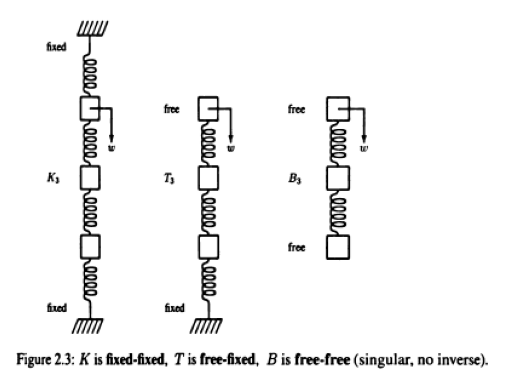

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"images\2-3.png")
plt.imshow(img)
plt.axis("off")
plt.show()